<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>K-Means From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Implement K-Means as a reusable class, without using sklearn.</li>
<li>Track and visualize the cost function (inertia) over iterations.</li>
<li>Implement K-Means++ initialization to fix the "bad random start" problem.</li>
<li>Use the Elbow Method to choose a good value of K.</li>
</ol>
In the previous notebook, I manually walked through the assign and update 
loop. Now I'll wrap all of that into a clean, reusable 
<b>KMeans class</b> just like a mini version of sklearn's implementation.
</div>

In [ ]:
# Only numpy and matplotlib - no sklearn for the algorithm itself

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Creating Synthetic Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Same as before - synthetic data with a few natural groups, so we 
can visually verify our implementation works correctly.
</div>

Data shape: (300, 2)


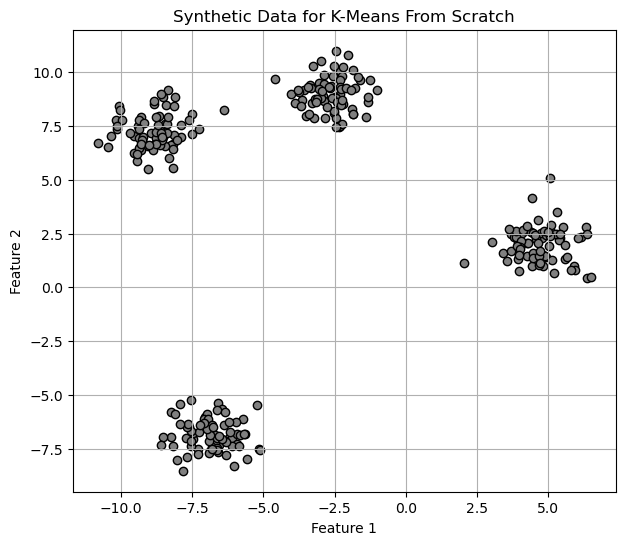

In [3]:
# Generating synthetic data with 4 natural clusters
np.random.seed(42)
X, true_labels = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

print("Data shape:", X.shape)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', edgecolors='k')
plt.title("Synthetic Data for K-Means From Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Cost Function: Inertia (WCSS)</b>
</h2>
<div style="font-family:'Times New Roman';">
Before writing the algorithm, let's understand <b>what K-Means is 
actually trying to minimize</b>.
<br><br>
K-Means tries to minimize the <b>Within-Cluster Sum of Squares (WCSS)</b>, 
also called <b>inertia</b>:
<br><br>
<b>Inertia = Σ Σ ||x - centroid_k||²</b>
<br><br>
In plain words: for every point, calculate the squared distance to 
its assigned centroid, and add up all these squared distances 
across all clusters.
<br><br>
A <b>lower inertia</b> means points are, on average, closer to 
their centroids i.e., tighter, more compact clusters. 
Each iteration of K-Means (assign + update) is mathematically 
guaranteed to <b>never increase</b> this value which is why 
the algorithm converges.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Problem with Random Initialization</b>
</h2>
<div style="font-family:'Times New Roman';">
In the previous notebook, we picked initial centroids by randomly 
selecting K points from the data. The problem? 
<b>K-Means can get "stuck" in a bad solution depending on where 
the centroids start.</b>
<br><br>
For example, if two initial centroids happen to land very close 
to each other, the algorithm might end up splitting one true 
cluster into two, while merging two other true clusters into one - 
and never recover from this, since each step only ever 
<i>improves</i> from the current position (it doesn't "restart").
<br><br>
<b>K-Means++</b> is a smarter initialization strategy that tries to 
spread out the initial centroids:
<ol>
<li>Pick the first centroid <b>randomly</b> from the data points.</li>
<li>For each remaining point, calculate its distance to the 
<b>nearest already-chosen centroid</b>.</li>
<li>Pick the next centroid <b>randomly, but with probability 
proportional to this distance squared</b> - so points 
<i>far away</i> from existing centroids are more likely to be 
chosen.</li>
<li>Repeat until we have K centroids.</li>
</ol>
This gives the algorithm a much better starting point, almost 
always leading to better final clusters.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Implementing the KMeans Class</b>
</h2>
<div style="font-family:'Times New Roman';">
Now let's put everything together into a class with:
<ul>
<li><b>_init_centroids():</b> K-Means++ initialization.</li>
<li><b>_assign_clusters():</b> assign each point to its nearest centroid.</li>
<li><b>_update_centroids():</b> recalculate centroids as the mean of their points.</li>
<li><b>_compute_inertia():</b> calculate the WCSS for tracking convergence.</li>
<li><b>fit():</b> runs the full algorithm, repeating until convergence.</li>
<li><b>predict():</b> assigns new points to the learned centroids.</li>
</ul>
</div>

In [4]:
class KMeans:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4, random_state=None):
        # n_clusters -> number of clusters (K)
        # max_iters -> maximum number of assign-update iterations
        # tol -> if centroids move less than this, we consider it converged
        # random_state -> seed for reproducibility
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state

        # These will be set after fit()
        self.centroids = None
        self.labels_ = None
        self.inertia_history_ = []  # to track cost over iterations

    def _init_centroids(self, X):
        """
        K-Means++ initialization: spreads out initial centroids
        instead of picking them all randomly.
        """
        rng = np.random.default_rng(self.random_state)
        n_samples = X.shape[0]

        centroids = []

        # Step 1: Pick the first centroid randomly from the data
        first_idx = rng.integers(n_samples)
        centroids.append(X[first_idx])

        # Step 2-4: Pick remaining centroids based on distance
        for _ in range(1, self.n_clusters):
            # Calculating distance from each point to its NEAREST chosen centroid
            distances = np.array([
                min(np.sum((x - c) ** 2) for c in centroids)
                for x in X
            ])

            # Converting distances to probabilities (farther points = higher probability)
            probabilities = distances / distances.sum()

            # Picking the next centroid based on these probabilities
            next_idx = rng.choice(n_samples, p=probabilities)
            centroids.append(X[next_idx])

        return np.array(centroids)

    def _assign_clusters(self, X):
        """
        Assigns each point in X to the nearest centroid.
        Returns an array of cluster labels.
        """
        distances = np.zeros((X.shape[0], self.n_clusters))

        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.sqrt(((X - centroid) ** 2).sum(axis=1))

        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        """
        Recalculates centroids as the mean of all points assigned to each cluster.
        """
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))

        for k in range(self.n_clusters):
            points_in_cluster = X[labels == k]

            if len(points_in_cluster) > 0:
                new_centroids[k] = points_in_cluster.mean(axis=0)
            else:
                # Edge case: if a cluster ends up with NO points,
                # keep its old centroid unchanged
                new_centroids[k] = self.centroids[k]

        return new_centroids

    def _compute_inertia(self, X, labels):
        """
        Computes the Within-Cluster Sum of Squares (WCSS).
        """
        inertia = 0
        for k in range(self.n_clusters):
            points_in_cluster = X[labels == k]
            inertia += np.sum((points_in_cluster - self.centroids[k]) ** 2)

        return inertia

    def fit(self, X):
        """
        Runs the K-Means algorithm: initialize, then repeatedly
        assign and update until convergence.
        """
        # Step 0: Initialize centroids using K-Means++
        self.centroids = self._init_centroids(X)
        self.inertia_history_ = []

        for iteration in range(self.max_iters):
            # Step 1: Assign points to nearest centroid
            labels = self._assign_clusters(X)

            # Tracking inertia BEFORE updating centroids
            inertia = self._compute_inertia(X, labels)
            self.inertia_history_.append(inertia)

            # Step 2: Update centroids
            new_centroids = self._update_centroids(X, labels)

            # Checking for convergence: how much did centroids move?
            shift = np.sqrt(((new_centroids - self.centroids) ** 2).sum(axis=1)).max()

            self.centroids = new_centroids

            if shift < self.tol:
                print(f"Converged after {iteration + 1} iterations.")
                break

        self.labels_ = self._assign_clusters(X)
        return self

    def predict(self, X):
        """
        Assigns new data points to the nearest learned centroid.
        """
        return self._assign_clusters(X)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Training K-Means on Our Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's create an instance of our KMeans class with K=4 (since we 
generated 4 natural clusters) and fit it on the data.
</div>

In [5]:
# Creating and training the model
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

print("Final centroids:")
print(kmeans.centroids)
print("\nNumber of iterations until convergence:", len(kmeans.inertia_history_))

Converged after 2 iterations.
Final centroids:
[[-8.83330596  7.21790214]
 [ 4.70253968  2.02807134]
 [-6.84180708 -6.84038791]
 [-2.63715917  8.98563949]]

Number of iterations until convergence: 2


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing the Final Clusters</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's plot the data colored by the clusters our model found, along 
with the final centroid positions.
</div>

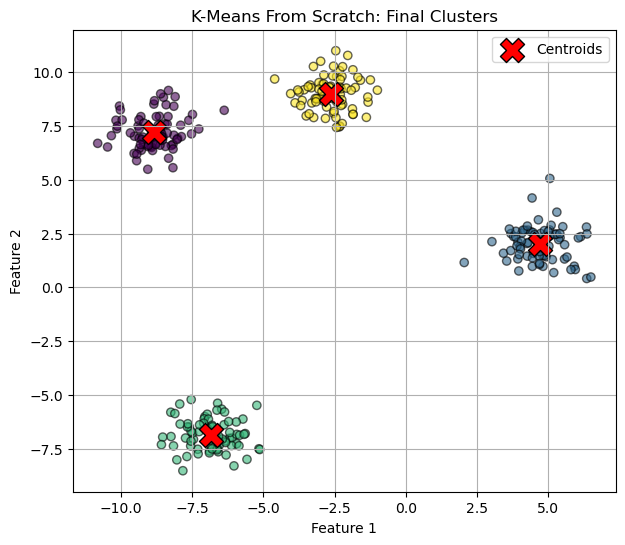

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', edgecolors='k', alpha=0.6)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='X', s=300, label='Centroids', edgecolors='black')

plt.title("K-Means From Scratch: Final Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing Convergence: Inertia Over Iterations</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's plot how the <b>inertia (WCSS)</b> decreased over each 
iteration. We should see it <b>drop quickly at first</b> and then 
<b>flatten out</b> as the algorithm converges this flattening is 
exactly what "convergence" looks like numerically.
</div>

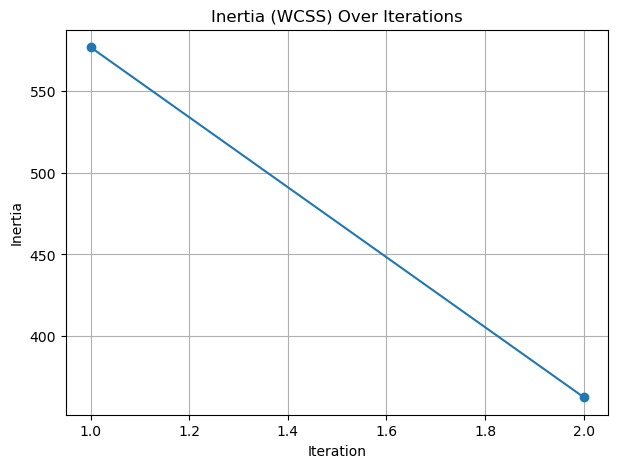

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(kmeans.inertia_history_) + 1), kmeans.inertia_history_, 
         marker='o', color='#1f77b4')

plt.title("Inertia (WCSS) Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Comparing K-Means++ vs Plain Random Initialization</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's actually verify that K-Means++ helps. I'll add a simple 
"random init" option to compare against, run both several times 
with different seeds, and compare the <b>final inertia</b> values.
<br><br>
Lower final inertia = tighter, better clusters. If K-Means++ is 
working as expected, it should consistently produce 
<b>lower (or equal) final inertia</b> compared to plain random 
initialization, especially when we get unlucky with the random seed.
</div>

Converged after 2 iterations.
Converged after 12 iterations.
Converged after 2 iterations.
Converged after 12 iterations.
Converged after 2 iterations.
Converged after 4 iterations.
Converged after 2 iterations.
Converged after 8 iterations.
Converged after 2 iterations.
Converged after 4 iterations.
Converged after 2 iterations.
Converged after 4 iterations.
Converged after 2 iterations.
Converged after 4 iterations.
Converged after 2 iterations.
Converged after 4 iterations.
Converged after 2 iterations.
Converged after 9 iterations.
Converged after 2 iterations.
Converged after 3 iterations.


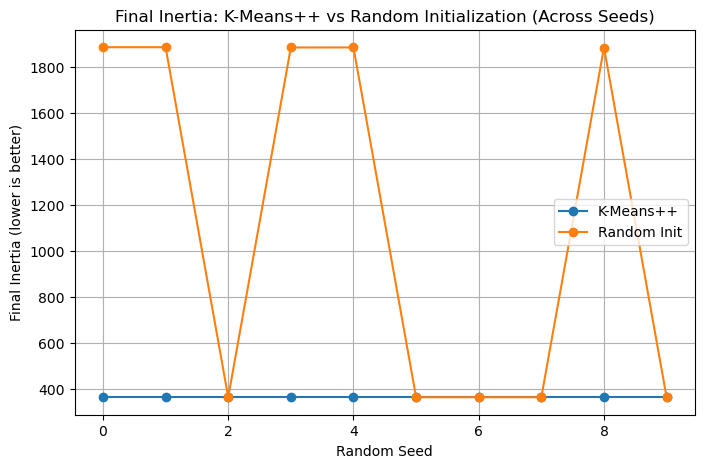

In [8]:
class KMeansRandomInit(KMeans):
    """
    A version of KMeans that uses plain random initialization
    (picking K random data points), instead of K-Means++.
    Used here only for comparison.
    """

    def _init_centroids(self, X):
        rng = np.random.default_rng(self.random_state)
        random_indices = rng.choice(X.shape[0], self.n_clusters, replace=False)
        return X[random_indices].copy()


# Running both versions across several random seeds
seeds = range(10)

kmeanspp_inertias = []
random_inertias = []

for seed in seeds:
    model_pp = KMeans(n_clusters=4, random_state=seed)
    model_pp.fit(X)
    kmeanspp_inertias.append(model_pp.inertia_history_[-1])

    model_random = KMeansRandomInit(n_clusters=4, random_state=seed)
    model_random.fit(X)
    random_inertias.append(model_random.inertia_history_[-1])

# Plotting comparison
plt.figure(figsize=(8, 5))
plt.plot(seeds, kmeanspp_inertias, marker='o', label='K-Means++')
plt.plot(seeds, random_inertias, marker='o', label='Random Init')

plt.title("Final Inertia: K-Means++ vs Random Initialization (Across Seeds)")
plt.xlabel("Random Seed")
plt.ylabel("Final Inertia (lower is better)")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Choosing K: The Elbow Method</b>
</h2>
<div style="font-family:'Times New Roman';">
So far, we've assumed we already know K=4. But in real problems, 
<b>we don't know how many clusters exist</b> in the data!
<br><br>
The <b>Elbow Method</b> helps with this:
<ol>
<li>Run K-Means for a range of K values (e.g., K=1 to K=10).</li>
<li>For each K, record the final <b>inertia</b>.</li>
<li>Plot K vs Inertia.</li>
</ol>
As K increases, inertia will <b>always decrease</b> (more clusters 
= points are closer to their centroids). But at some point, adding 
more clusters gives <b>diminishing returns</b> - the inertia drops 
much more slowly. This point looks like an "elbow" in the plot, and 
it's usually a good choice for K.
</div>

Converged after 2 iterations.
Converged after 3 iterations.
Converged after 2 iterations.
Converged after 2 iterations.
Converged after 11 iterations.
Converged after 11 iterations.
Converged after 11 iterations.
Converged after 11 iterations.
Converged after 11 iterations.
Converged after 8 iterations.


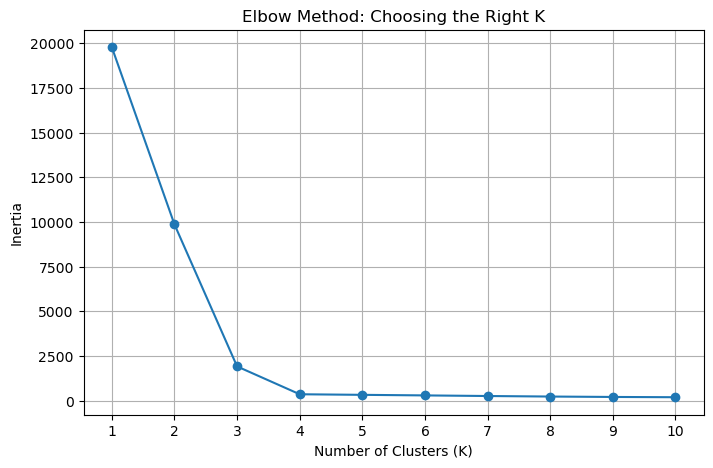

In [9]:
# Trying K from 1 to 10
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_history_[-1])

# Plotting the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='#1f77b4')

plt.title("Elbow Method: Choosing the Right K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Reading the Elbow Plot</b>
</h2>
<div style="font-family:'Times New Roman';">
Looking at the plot above, you should notice the inertia drops 
sharply from K=1 to K=4, and then the curve starts to 
<b>flatten out</b> - the "elbow" appears around <b>K=4</b>, which 
matches exactly the number of clusters we used to generate the data!
<br><br>
In real-world data, the elbow often isn't this clean - it's more 
of a judgment call, and you'd usually combine this with domain 
knowledge (e.g., "we want to segment customers into 3-5 marketing 
groups, so let's look at K=3 to K=5").
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Implemented a complete, reusable <b>KMeans class from scratch</b>, 
including <b>K-Means++ initialization</b>.</li>
<li>Understood and visualized <b>inertia (WCSS)</b> - the cost 
function K-Means minimizes.</li>
<li>Confirmed that <b>K-Means++</b> generally leads to better (lower) 
final inertia compared to plain random initialization.</li>
<li>Used the <b>Elbow Method</b> to systematically choose a good 
value of K, and verified it matched our synthetic data's true 
structure.</li>
</ul>
Next, I'll apply this implementation (or sklearn's version) to a 
<b>real-world dataset</b> - perhaps customer segmentation - to see 
K-Means in action on actual data.
</div>